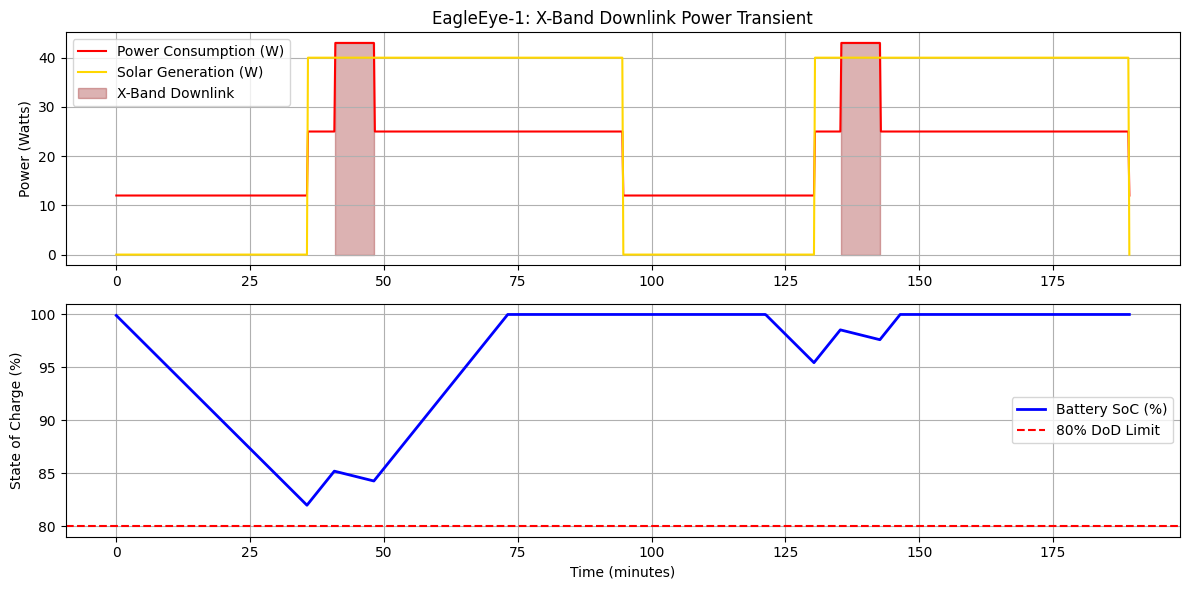

In [1]:
# EPS & COMMS: X-Band Downlink Power Transient Analysis
# EagleEye-1 Mission

import numpy as np
import matplotlib.pyplot as plt

# 1. ORBIT & COMMS PARAMETERS
period_min = 94.62
eclipse_min = 35.76
downlink_duration_min = 7.38

# 2. POWER BUDGET (Watts)
P_eclipse = 12.0
P_sunlight = 25.0
P_xband_tx = 18.0  # Peak power for X-Band transmitter
P_solar_gen = 40.0
C_bat_Wh = 39.73   # Battery capacity

# 3. TIME ARRAY (Simulating 2 orbits)
t_total = period_min * 2
time = np.linspace(0, t_total, 1000)

# 4. POWER DRAW LOGIC
t_in_orbit = time % period_min

# Base load
power_draw = np.where(t_in_orbit <= eclipse_min, P_eclipse, P_sunlight)

# Worst-case scenario: Downlink starts right after eclipse
downlink_start = eclipse_min + 5.0 
downlink_end = downlink_start + downlink_duration_min

is_downlink = np.logical_and(t_in_orbit >= downlink_start, t_in_orbit <= downlink_end)
power_draw = np.where(is_downlink, power_draw + P_xband_tx, power_draw)

# 5. ENERGY BALANCE & BATTERY SOC
solar_power = np.where(t_in_orbit <= eclipse_min, 0.0, P_solar_gen)
net_power_W = solar_power - power_draw

# Convert Watts to Watt-hours and integrate
dt_hours = (time[1] - time[0]) / 60.0
energy_change_Wh = net_power_W * dt_hours

energy_levels = C_bat_Wh + np.cumsum(energy_change_Wh)
energy_levels = np.clip(energy_levels, a_min=0, a_max=C_bat_Wh)

soc_percent = (energy_levels / C_bat_Wh) * 100.0

# 6. VISUALIZATION
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(time, power_draw, color='red', label='Power Consumption (W)')
plt.plot(time, solar_power, color='gold', label='Solar Generation (W)')
plt.fill_between(time, 0, power_draw, where=is_downlink, color='darkred', alpha=0.3, label='X-Band Downlink')
plt.ylabel('Power (Watts)')
plt.title('EagleEye-1: X-Band Downlink Power Transient')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, soc_percent, color='blue', linewidth=2, label='Battery SoC (%)')
plt.axhline(y=80.0, color='red', linestyle='--', label='80% DoD Limit')
plt.xlabel('Time (minutes)')
plt.ylabel('State of Charge (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()